# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load Dataset

In [12]:
data = pd.read_excel('Data_AF.xlsx')
data.head()

,Kabupaten/Kota Se Jawa Timur,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan,Jumlah Pelanggan Air Bersih,Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,Jumlah Penduduk Bekerja 15 Tahun Keatas,Jumlah Penduduk Sekolah 15 Tahun Keatas,Distribusi Penduduk,...,Ruta miskin yg menggunakan air layak,Ruta miskin yg menggunakan jamban,Ruta miskin penerima raskin,Gini Rasio,Indeks Keparahan Kemiskinan (P2),Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun,Indeks Pembangunan Manusia,Angka Kesakitan,Produksi Padi,PDRB Atas Dasar Harga Konstan 2010
0,Kabupaten Pacitan,0.91,79.62,52.53,18973,47.47,1918550,348768,23213,1.40,...,56.27,98.93,87.32,0.398,0.34,7.28,69.28,13.58,91941.66,11040.8
1,Kabupaten Ponorogo,3.50,71.15,49.00,21785,51.00,1912086,485697,49232,2.19,...,89.59,74.60,90.42,0.346,0.40,7.21,71.57,21.45,322205.50,14297.1
2,Kabupaten Trenggalek,3.36,73.45,49.33,14180,50.67,1819027,399122,35169,1.75,...,41.82,69.40,90.81,0.372,0.30,7.28,70.10,19.85,112213.57,12779.5
3,Kabupaten Tulungagung,3.29,70.48,49.89,24740,50.11,1833832,554475,59224,2.62,...,71.39,95.19,92.98,0.304,0.17,8.07,73.15,18.31,196430.58,27299.8
4,Kabupaten Blitar,3.05,72.93,49.63,14593,50.37,1975636,616952,47204,2.92,...,82.56,92.50,89.27,0.333,0.23,7.29,71.02,23.61,224027.19,25530.1


# check missing value

In [13]:
data.isnull().sum()

Kabupaten/Kota Se Jawa Timur                                        0
Tingkat Pengangguran Terbuka                                        0
Tingkat Partisipasi Angkatan Kerja                                  0
Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan           0
Jumlah Pelanggan Air Bersih                                         0
Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan     0
Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal                   0
Jumlah Penduduk Bekerja 15 Tahun Keatas                             0
Jumlah Penduduk Sekolah 15 Tahun Keatas                             0
Distribusi Penduduk                                                 0
Persentase Perempuan Kawin di Bawah Umur                            0
Rasio Jenis Kelamin                                                 0
Angka Melek Huruf penduduk miskin 15-55tahun                        0
Ruta miskin yg menggunakan air layak                                0
Ruta miskin yg mengg

# handling missing value

In [14]:
data.fillna(data.mean(numeric_only=True), inplace=True)
data.head()

,Kabupaten/Kota Se Jawa Timur,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan,Jumlah Pelanggan Air Bersih,Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,Jumlah Penduduk Bekerja 15 Tahun Keatas,Jumlah Penduduk Sekolah 15 Tahun Keatas,Distribusi Penduduk,...,Ruta miskin yg menggunakan air layak,Ruta miskin yg menggunakan jamban,Ruta miskin penerima raskin,Gini Rasio,Indeks Keparahan Kemiskinan (P2),Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun,Indeks Pembangunan Manusia,Angka Kesakitan,Produksi Padi,PDRB Atas Dasar Harga Konstan 2010
0,Kabupaten Pacitan,0.91,79.62,52.53,18973,47.47,1918550,348768,23213,1.40,...,56.27,98.93,87.32,0.398,0.34,7.28,69.28,13.58,91941.66,11040.8
1,Kabupaten Ponorogo,3.50,71.15,49.00,21785,51.00,1912086,485697,49232,2.19,...,89.59,74.60,90.42,0.346,0.40,7.21,71.57,21.45,322205.50,14297.1
2,Kabupaten Trenggalek,3.36,73.45,49.33,14180,50.67,1819027,399122,35169,1.75,...,41.82,69.40,90.81,0.372,0.30,7.28,70.10,19.85,112213.57,12779.5
3,Kabupaten Tulungagung,3.29,70.48,49.89,24740,50.11,1833832,554475,59224,2.62,...,71.39,95.19,92.98,0.304,0.17,8.07,73.15,18.31,196430.58,27299.8
4,Kabupaten Blitar,3.05,72.93,49.63,14593,50.37,1975636,616952,47204,2.92,...,82.56,92.50,89.27,0.333,0.23,7.29,71.02,23.61,224027.19,25530.1


# Menghapus nama Kabupaten dan No

In [22]:
nama_kabupaten = data['Kabupaten/Kota Se Jawa Timur']
data_cluster = data.drop(columns=[ 'Kabupaten/Kota Se Jawa Timur'])

print("Data setelah atribut kabupaten di hapus")
display(data_cluster.head())

print("Summary statistik")
data_cluster.describe()

Data setelah atribut kabupaten di hapus


,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan,Jumlah Pelanggan Air Bersih,Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,Jumlah Penduduk Bekerja 15 Tahun Keatas,Jumlah Penduduk Sekolah 15 Tahun Keatas,Distribusi Penduduk,Persentase Perempuan Kawin di Bawah Umur,...,Ruta miskin yg menggunakan air layak,Ruta miskin yg menggunakan jamban,Ruta miskin penerima raskin,Gini Rasio,Indeks Keparahan Kemiskinan (P2),Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun,Indeks Pembangunan Manusia,Angka Kesakitan,Produksi Padi,PDRB Atas Dasar Harga Konstan 2010
0,0.91,79.62,52.53,18973,47.47,1918550,348768,23213,1.40,14.38,...,56.27,98.93,87.32,0.398,0.34,7.28,69.28,13.58,91941.66,11040.8
1,3.50,71.15,49.00,21785,51.00,1912086,485697,49232,2.19,16.87,...,89.59,74.60,90.42,0.346,0.40,7.21,71.57,21.45,322205.50,14297.1
2,3.36,73.45,49.33,14180,50.67,1819027,399122,35169,1.75,22.25,...,41.82,69.40,90.81,0.372,0.30,7.28,70.10,19.85,112213.57,12779.5
3,3.29,70.48,49.89,24740,50.11,1833832,554475,59224,2.62,15.17,...,71.39,95.19,92.98,0.304,0.17,8.07,73.15,18.31,196430.58,27299.8
4,3.05,72.93,49.63,14593,50.37,1975636,616952,47204,2.92,20.01,...,82.56,92.50,89.27,0.333,0.23,7.29,71.02,23.61,224027.19,25530.1


Summary statistik


,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,Persentase Pengeluaran Perkapita Sebulan Kelompok Makanan,Jumlah Pelanggan Air Bersih,Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan,Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal,Jumlah Penduduk Bekerja 15 Tahun Keatas,Jumlah Penduduk Sekolah 15 Tahun Keatas,Distribusi Penduduk,Persentase Perempuan Kawin di Bawah Umur,...,Ruta miskin yg menggunakan air layak,Ruta miskin yg menggunakan jamban,Ruta miskin penerima raskin,Gini Rasio,Indeks Keparahan Kemiskinan (P2),Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun,Indeks Pembangunan Manusia,Angka Kesakitan,Produksi Padi,PDRB Atas Dasar Harga Konstan 2010
count,38.000000,38.000000,38.000000,38.000000,38.000000,3.800000e+01,3.800000e+01,38.000000,38.000000,38.000000,...,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,3.653947,69.648158,50.261316,56521.842105,49.738684,2.165218e+06,5.381566e+05,61261.763158,2.631579,19.567632,...,69.129737,76.100789,76.478684,0.324921,0.383421,7.798158,72.950263,17.117632,252129.838947,44052.152632
std,1.080297,3.470277,5.770744,96510.907508,5.770744,4.774494e+05,3.303333e+05,48057.401520,1.684275,9.250350,...,14.276156,16.168388,19.276304,0.035604,0.235742,1.615808,4.697626,4.092143,219490.106766,69027.998073
min,0.910000,63.440000,36.600000,5236.000000,37.460000,1.562340e+06,6.683300e+04,7596.000000,0.320000,7.040000,...,41.820000,32.100000,20.090000,0.267000,0.050000,4.550000,64.750000,8.290000,3565.880000,4832.900000
25%,2.890000,66.890000,46.675000,19428.000000,46.297500,1.834726e+06,3.789848e+05,34203.750000,1.720000,13.532500,...,57.682500,67.882500,70.462500,0.304250,0.230000,6.852500,69.360000,15.117500,91470.405000,13180.725000
50%,3.590000,69.210000,50.375000,24716.000000,49.625000,2.004876e+06,5.127485e+05,50829.000000,2.555000,18.135000,...,66.920000,78.485000,82.335000,0.318500,0.335000,7.460000,72.315000,17.050000,223432.505000,22979.350000
75%,4.225000,72.037500,53.702500,43596.750000,53.325000,2.422863e+06,6.315382e+05,71907.250000,3.112500,23.377500,...,82.162500,88.830000,89.772500,0.338750,0.430000,8.967500,76.065000,19.630000,343116.225000,53733.700000
max,5.880000,79.620000,62.540000,574173.000000,63.400000,3.405633e+06,1.426945e+06,228815.000000,7.300000,45.600000,...,96.280000,98.930000,99.070000,0.421000,1.080000,11.130000,82.760000,27.140000,839724.430000,410879.300000


# Visualiasasi Boxplot Distribusi data

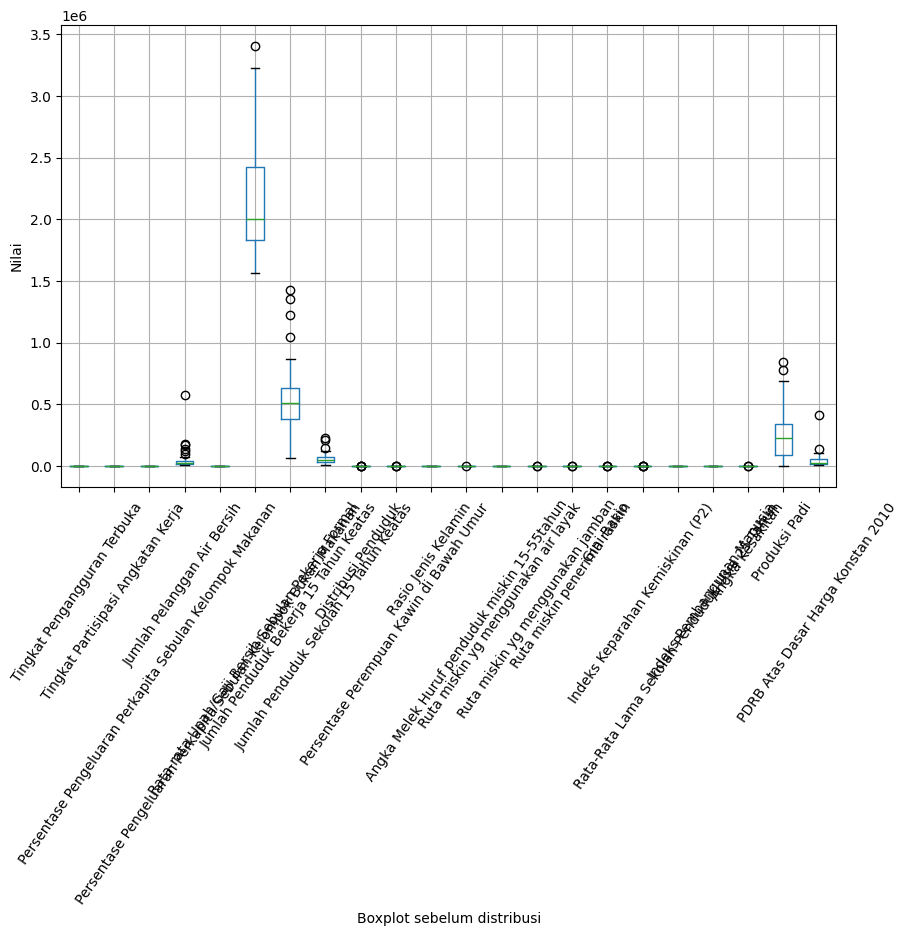

In [26]:
plt.figure(figsize=(10, 6))
data_cluster.boxplot(rot=55)
plt.xlabel('Boxplot sebelum distribusi')
plt.ylabel('Nilai')
plt.show()

# Check Skewness dan transformasi data skew

In [ ]:
skew_awal = data_cluster.skew()
print('Data skewness awal')
display(skew_awal.sort_values(ascending=False))

Data skewness awal


Jumlah Pelanggan Air Bersih                                         4.496641
PDRB Atas Dasar Harga Konstan 2010                                  4.348784
Jumlah Penduduk Sekolah 15 Tahun Keatas                             2.002912
Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal                   1.170610
Indeks Keparahan Kemiskinan (P2)                                    1.104296
Persentase Perempuan Kawin di Bawah Umur                            1.065648
Produksi Padi                                                       1.010569
Distribusi Penduduk                                                 1.009928
Jumlah Penduduk Bekerja 15 Tahun Keatas                             0.905830
Gini Rasio                                                          0.899389
Tingkat Partisipasi Angkatan Kerja                                  0.525647
Indeks Pembangunan Manusia                                          0.487922
Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan     0.328738

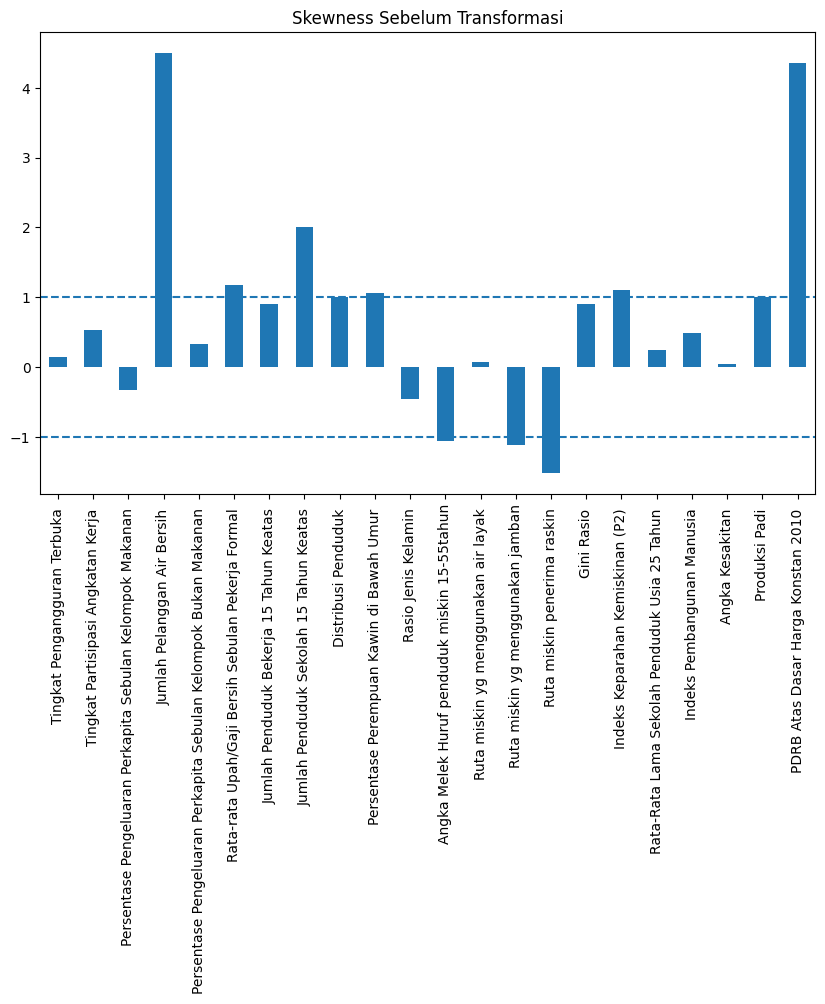

In [30]:
skew_awal.plot(kind='bar', figsize=(10, 6), title='Skewness Sebelum Transformasi')
plt.axhline(1, linestyle='--')
plt.axhline(-1, linestyle='--')
plt.show()

data_transform = data_cluster.copy()

In [31]:
for col in data_transform.columns:
    if abs (data_transform[col].skew()) > 1:
        data_transform[col] = np.log(data_transform[col])

skew_akhir = data_transform.skew()
print("\nSkewness setelah transformasi:")
display(skew_akhir.sort_values(ascending=False))


Skewness setelah transformasi:


Jumlah Pelanggan Air Bersih                                         0.927413
Jumlah Penduduk Bekerja 15 Tahun Keatas                             0.905830
Gini Rasio                                                          0.899389
Rata-rata Upah/Gaji Bersih Sebulan Pekerja Formal                   0.835610
PDRB Atas Dasar Harga Konstan 2010                                  0.651964
Tingkat Partisipasi Angkatan Kerja                                  0.525647
Indeks Pembangunan Manusia                                          0.487922
Persentase Pengeluaran Perkapita Sebulan Kelompok Bukan Makanan     0.328738
Rata-Rata Lama Sekolah Penduduk Usia 25 Tahun                       0.245800
Tingkat Pengangguran Terbuka                                        0.150088
Ruta miskin yg menggunakan air layak                                0.069349
Angka Kesakitan                                                     0.043388
Persentase Perempuan Kawin di Bawah Umur                           -0.125309

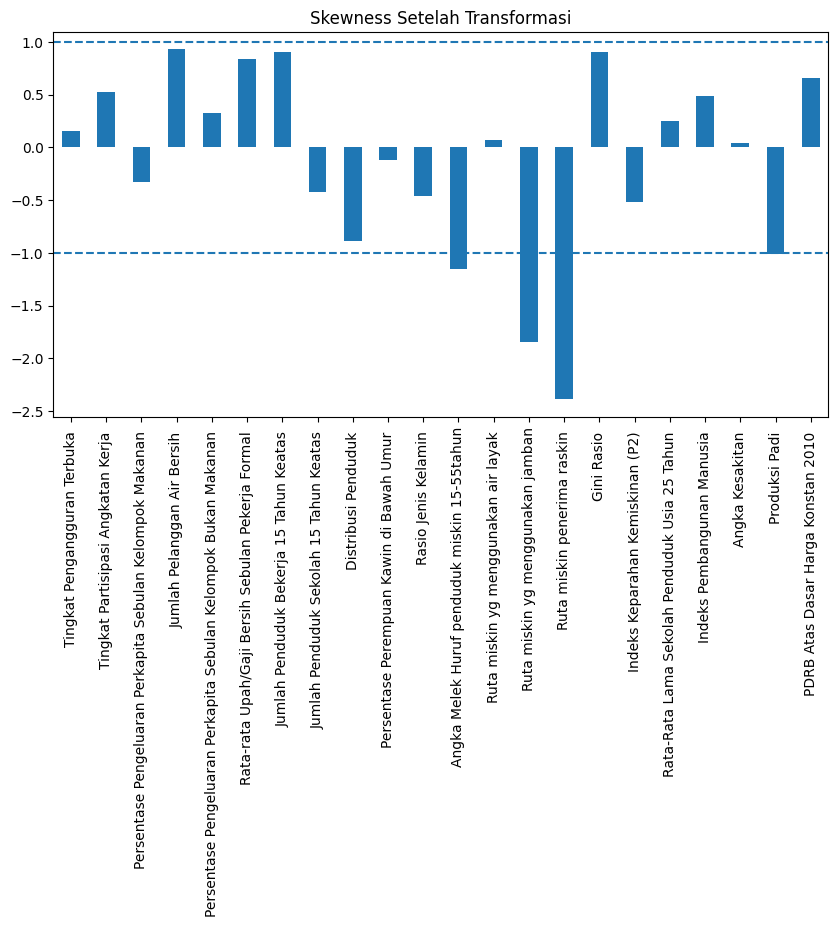

In [32]:
skew_akhir.plot(kind='bar', figsize=(10,5), title='Skewness Setelah Transformasi')
plt.axhline(1, linestyle='--')
plt.axhline(-1, linestyle='--')
plt.show()

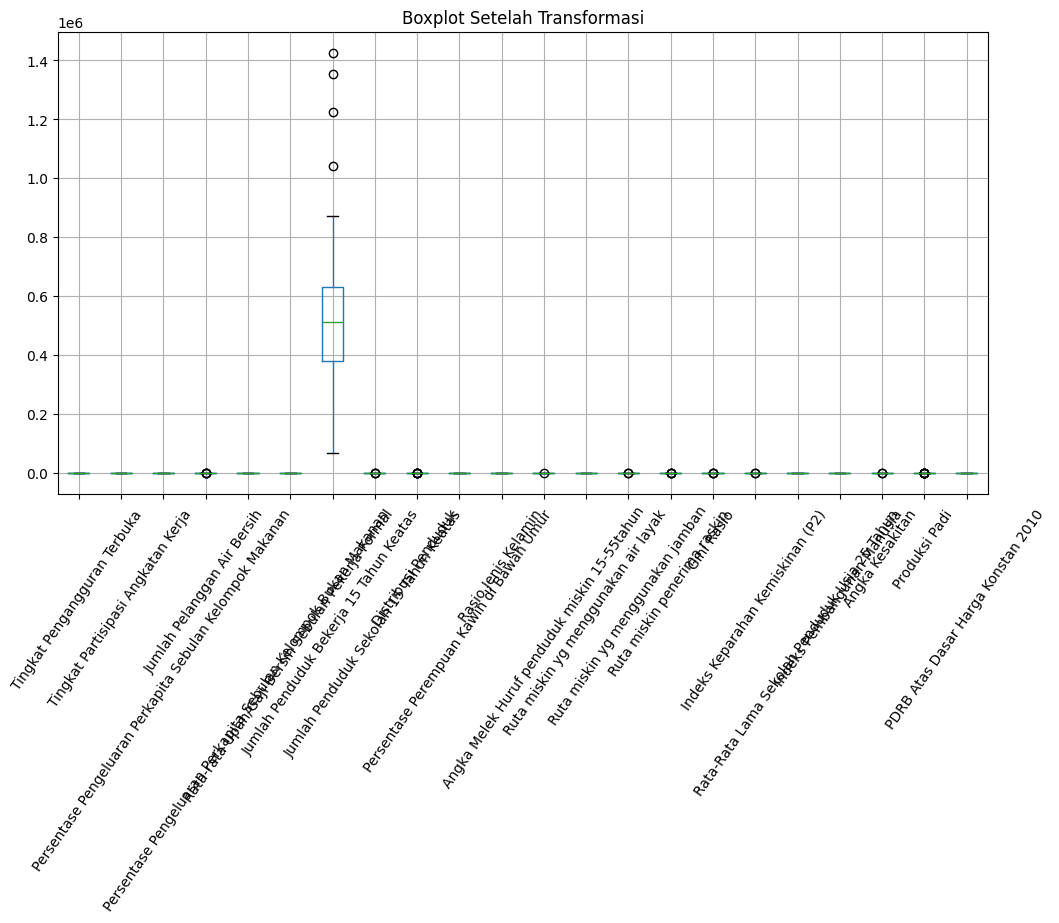

In [34]:
data_transform.boxplot(figsize=(12,6), rot=55)
plt.title('Boxplot Setelah Transformasi')
plt.show()